In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
from pathlib import Path
import pytensor
from tqdm import tqdm
import xarray as xr
import warnings
import seaborn as sns

warnings.filterwarnings("ignore")  # az.compare will throw warnings
plt.rcParams["figure.constrained_layout.use"] = True

# Individual level

In [2]:
hrd_path = Path.cwd().parent.parent / "data" / "hrd.csv"
hrd_df = pd.read_csv(hrd_path, index_col=0, low_memory=False)
participants_list = hrd_df.participant_id.unique()

In [73]:
missing_participants = []
model_comparison_df = pd.DataFrame([])

for participant_id in tqdm(participants_list):
    for session in [1, 2]:
        standard_path = (
            Path().cwd().parent.parent
            / "results"
            / "idata"
            / f"standard_model_session{session}_{participant_id}.nc"
        )

        cardiac_believing_path = (
            Path().cwd().parent.parent
            / "results"
            / "idata"
            / f"cardiac_believing_session{session}_{participant_id}.nc"
        )

        if (
            standard_path.exists()
            & cardiac_believing_path.exists()
        ):
            standard_idata = az.from_netcdf(standard_path)
            cardiac_believing_idata = az.from_netcdf(cardiac_believing_path)

            model_compare = az.compare(
                {
                    "standard": standard_idata,
                    "cardiac_beliefs": cardiac_believing_idata,
                },
            )
            model_compare["participant_id"] = participant_id
            model_compare["session"] = session
            model_comparison_df = pd.concat([model_comparison_df, model_compare])

        else:
            missing_participants.append((participant_id, session))

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 549/549 [04:19<00:00,  2.12it/s]


In [74]:
model_comparison_df["model"] = pd.Categorical(
    model_comparison_df.index,
    categories=["standard", "cardiac_beliefs"],
    ordered=True,
)
model_comparison_df = model_comparison_df.reset_index()

In [75]:
diff_model_1 = model_comparison_df[(model_comparison_df["index"] == "standard") & (model_comparison_df["rank"] == 1)].sort_values("elpd_diff").elpd_diff.to_numpy()
diff_se_model_1 = model_comparison_df[(model_comparison_df["index"] == "standard") & (model_comparison_df["rank"] == 1)].sort_values("elpd_diff").dse.to_numpy()

diff_model_2 = model_comparison_df[(model_comparison_df["index"] == "cardiac_beliefs") & (model_comparison_df["rank"] == 1)].sort_values("elpd_diff", ascending=False).elpd_diff.to_numpy()
diff_se_model_2 = model_comparison_df[(model_comparison_df["index"] == "cardiac_beliefs") & (model_comparison_df["rank"] == 1)].sort_values("elpd_diff", ascending=False).dse.to_numpy()

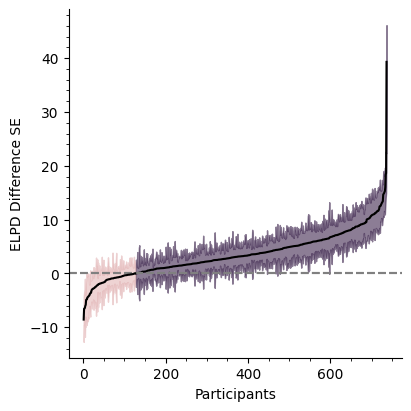

In [81]:
_, ax = plt.subplots(figsize=(4, 4))

x = np.arange(len(diff_model_1)) + len(diff_model_2) + 1
ax.fill_between(x=x, y1=diff_model_1-diff_se_model_1, y2=diff_model_1+diff_se_model_1, color="#3f274f", alpha=.6)
ax.axhline(y=0, linestyle="--", color="gray")
ax.plot(x, diff_model_1, color="k")

x = np.arange(len(diff_model_2)) + 1
ax.fill_between(x=x, y1=-diff_model_2-diff_se_model_2, y2=-diff_model_2+diff_se_model_2, color="#e3b6b7", alpha=.6)
ax.axhline(y=0, linestyle="--", color="gray")
ax.plot(x, -diff_model_2, color="k")

ax.set(xlabel="Participants", ylabel="ELPD Difference SE")

ax.minorticks_on()
sns.despine()

plt.savefig(Path().cwd().parent.parent / "figures" / "figure_2_model_comparison.svg")

# Group level

In [4]:
missing_participants = []
participant_list = []
idata_list = {
    "standard": [],
    "cardiac_beliefs": [],
    "weigthed_update": [],
    "cardiac_hgf": [],
}

for participant_id in tqdm(participants_list[:10]):
    for session in [1, 2]:
        standard_path = (
            Path().cwd().parent.parent
            / "results"
            / "idata"
            / f"standard_model_session{session}_{participant_id}.nc"
        )

        weighted_update_path = (
            Path().cwd().parent.parent
            / "results"
            / "idata"
            / f"weighted_update_session{session}_{participant_id}.nc"
        )

        cardiac_believing_path = (
            Path().cwd().parent.parent
            / "results"
            / "idata"
            / f"cardiac_believing_session{session}_{participant_id}.nc"
        )

        cardiac_hgf_path = (
            Path().cwd().parent.parent
            / "results"
            / "idata"
            / f"cardiac_hgf_session{session}_{participant_id}.nc"
        )

        if (
            standard_path.exists()
            & weighted_update_path.exists()
            & cardiac_believing_path.exists()
            & cardiac_hgf_path.exists()
        ):
            idata_list["standard"].append(az.from_netcdf(standard_path))
            idata_list["cardiac_beliefs"].append(az.from_netcdf(cardiac_believing_path))
            idata_list["weigthed_update"].append(az.from_netcdf(weighted_update_path))
            idata_list["cardiac_hgf"].append(az.from_netcdf(cardiac_hgf_path))

            participant_list.append(participant_id)

        else:
            missing_participants.append((participant_id, session))

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:06<00:00,  1.55it/s]


In [5]:
group_level_idata = {}
for model in ["standard", "cardiac_beliefs", "weigthed_update", "cardiac_hgf"]:
    # concatenate log-likelihoods
    likelihoods = [idata.log_likelihood for idata in idata_list[model]]
    stacked_likelihoods = xr.concat(likelihoods, dim="bin_intero_dim_0")

    # concatenate posteriors
    posteriors = [idata.posterior for idata in idata_list[model]]
    stacked_posteriors = xr.concat(posteriors, dim="bin_intero_dim_0")

    group_level_idata[model] = az.InferenceData(
        posterior=stacked_posteriors,  # doesn't matter, just one example posterior
        log_likelihood=stacked_likelihoods,
    )

arviz - WARNING - Array contains NaN-value.


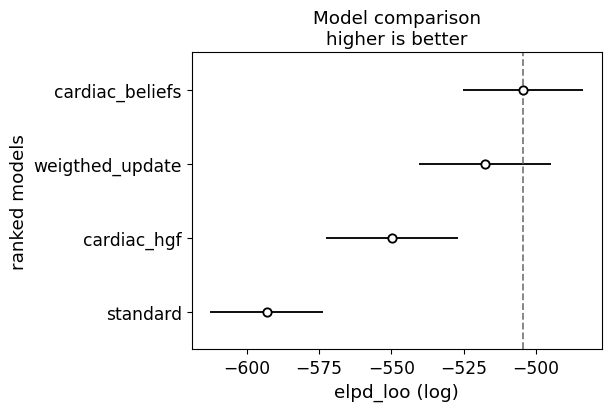

In [6]:
model_compare = az.compare(
    {
        "standard": group_level_idata["standard"],
        "cardiac_beliefs": group_level_idata["cardiac_beliefs"],
        "weigthed_update": group_level_idata["weigthed_update"],
        "cardiac_hgf": group_level_idata["cardiac_hgf"],
    },
)
az.plot_compare(model_compare);